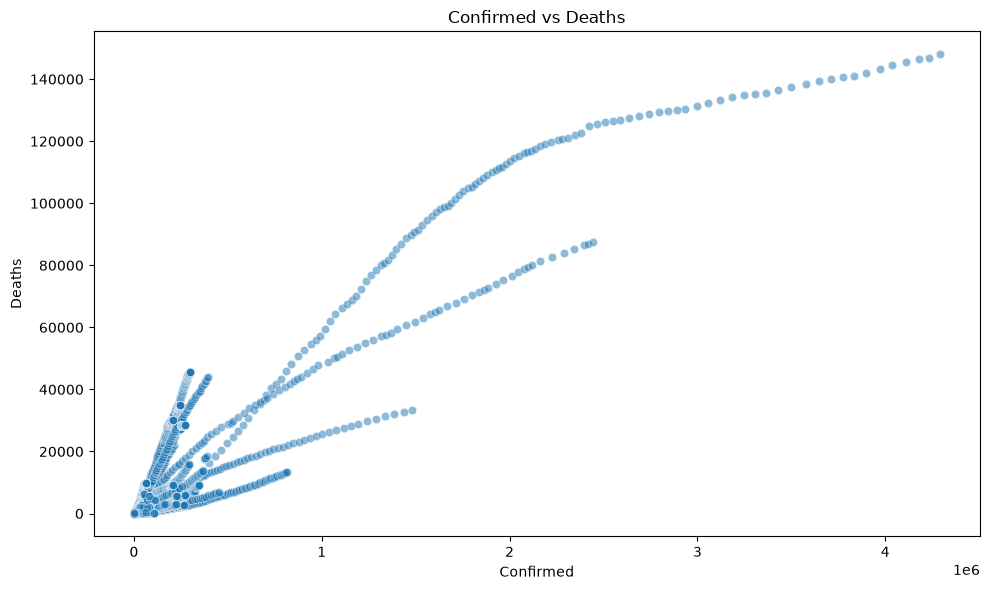

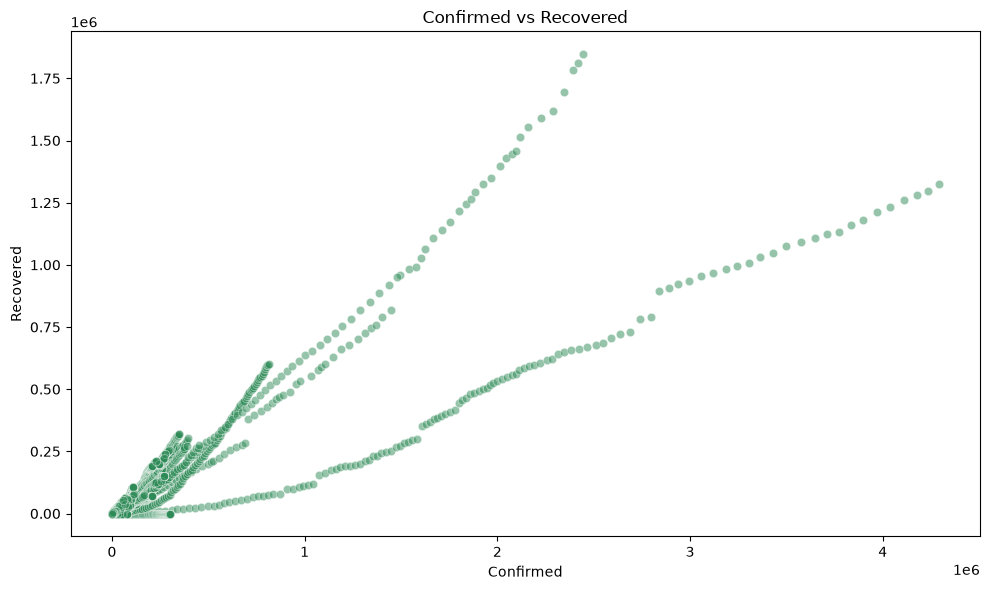

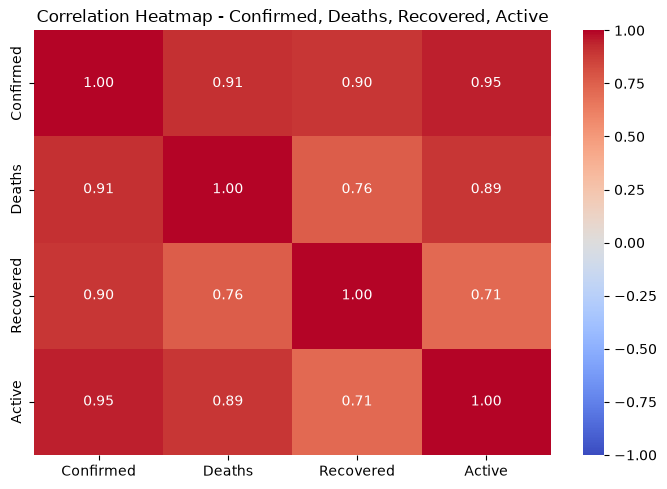

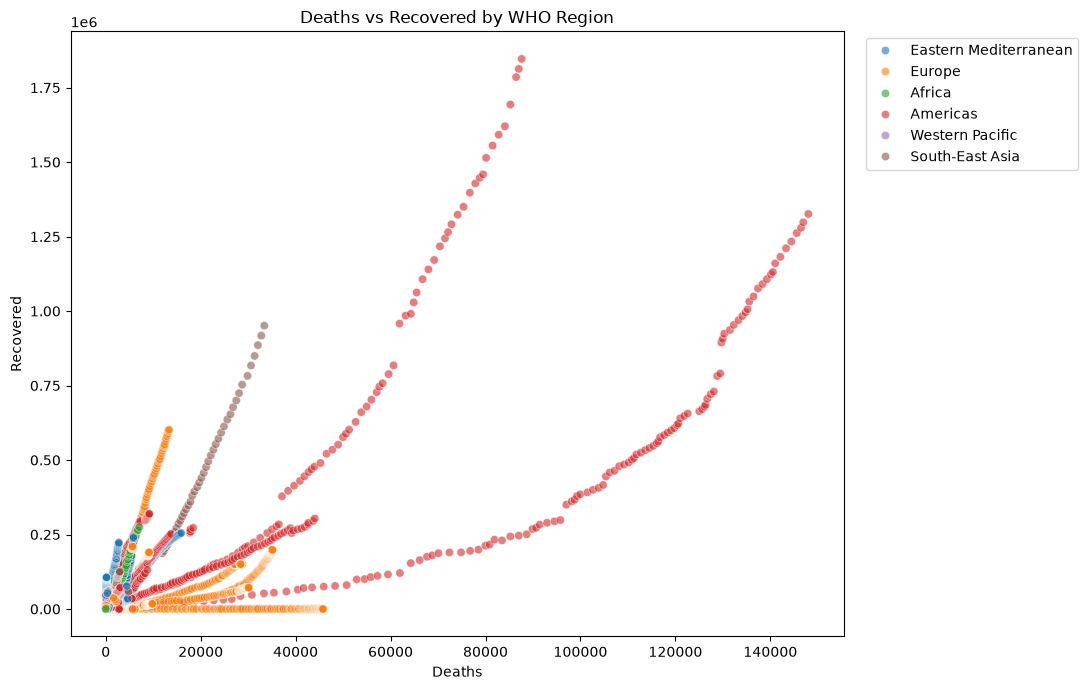

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Confirmed', y='Deaths', data=covid, alpha=0.5)
plt.title('Confirmed vs Deaths')
plt.xlabel('Confirmed')
plt.ylabel('Deaths')
plt.tight_layout()
plt.show()

# Points will cluster heavily near the bottom-left (most country-date rows have low case counts), with a small number of points stretching far to the upper-right (major outbreak countries like US, Brazil, India on later dates). The overall shape trends upward — as Confirmed increases, Deaths tends to increase too. This is confirmed numerically: the two are strongly correlated (r ≈ 0.91).

plt.figure(figsize=(10,6))
sns.scatterplot(x='Confirmed', y='Recovered', data=covid, alpha=0.5, color='seagreen')
plt.title('Confirmed vs Recovered')
plt.xlabel('Confirmed')
plt.ylabel('Recovered')
plt.tight_layout()
plt.show()

#Similar shape to #1 — dense cluster near the origin, sparse high-value outliers stretching out. Also a clear upward trend, and also strongly correlated (r ≈ 0.90) — more confirmed cases generally means more recovered cases too, which makes sense since recoveries are a downstream consequence of infections.

numeric_cols = ['Confirmed', 'Deaths', 'Recovered', 'Active']
corr = covid[numeric_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap - Confirmed, Deaths, Recovered, Active')
plt.tight_layout()
plt.show()

# Confirmed and Active are the most tightly linked (0.95) — makes sense, since active cases are directly derived from confirmed cases.
# Recovered and Active are the weakest pair (0.71) — the relationship between how many people are currently sick vs. how many have recovered is comparatively less tight, since recovery lags behind infection by varying amounts of time depending on the country's healthcare response.

plt.figure(figsize=(11,7))
sns.scatterplot(x='Deaths', y='Recovered', hue='WHO Region', data=covid, alpha=0.6)
plt.title('Deaths vs Recovered by WHO Region')
plt.xlabel('Deaths')
plt.ylabel('Recovered')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [43]:
from IPython.display import IFrame

daily_country = covid.groupby(['Date','Country/Region'])['Confirmed'].sum().reset_index()
daily_country['Date_str'] = daily_country['Date'].dt.strftime('%Y-%m-%d')

import plotly.express as px

fig = px.choropleth(
    daily_country,
    locations='Country/Region',
    locationmode='country names',
    color='Confirmed',
    color_continuous_scale='Reds',
    animation_frame='Date_str',
    title='Confirmed COVID-19 Cases Over Time'
)
# avoid nbformat rendering issue by exporting to HTML and embedding
fig.write_html('covid_choropleth.html', include_plotlyjs='cdn', full_html=False)
IFrame('covid_choropleth.html', width=900, height=600)

C:\Users\abdul\AppData\Local\Temp\ipykernel_14888\1091511100.py:8: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


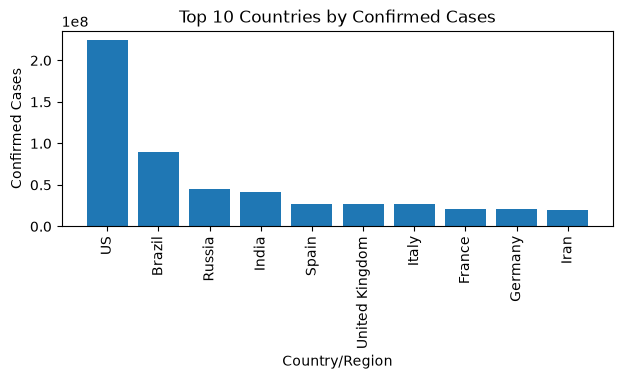

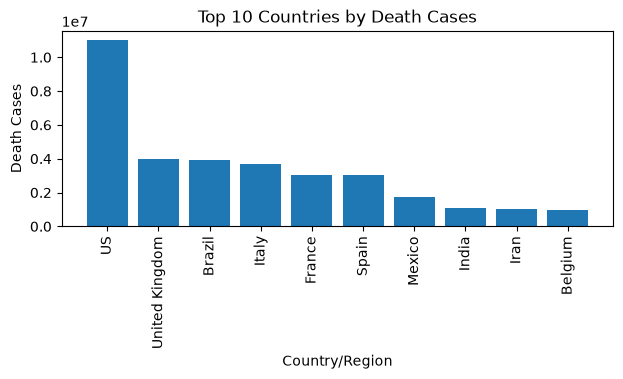

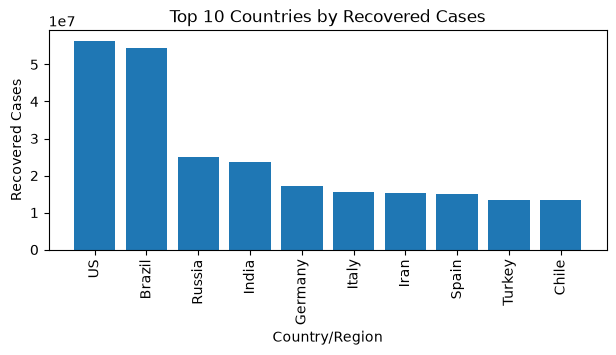

In [36]:
top_confirmed = covid.groupby("Country/Region")['Confirmed'].sum()
top_10 = top_confirmed.sort_values(ascending=False).head(10)


plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
plt.bar(top_10.index, top_10.values)
plt.title('Top 10 Countries by Confirmed Cases')
plt.xlabel('Country/Region')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=90)
plt.tight_layout()

#Again US topped the chart in terms of confirmed cases

top_death = covid.groupby("Country/Region")['Deaths'].sum()
top_10_death = top_death.sort_values(ascending=False).head(10)


plt.figure(figsize=(12,6))
plt.subplot(2,2,2)
plt.bar(top_10_death.index, top_10_death.values)
plt.title('Top 10 Countries by Death Cases')
plt.xlabel('Country/Region')
plt.ylabel('Death Cases')
plt.xticks(rotation=90)
plt.tight_layout()


#Interesting fact from the data : UK didnot handle the situation well and stood second in terms of death cases from covid while Russia handled that well

top_recovered = covid.groupby("Country/Region")['Recovered'].sum()
top_10_recovered = top_recovered.sort_values(ascending=False).head(10)


plt.figure(figsize=(12,6))
plt.subplot(2,2,3)
plt.bar(top_10_recovered.index, top_10_recovered.values)
plt.title('Top 10 Countries by Recovered Cases')
plt.xlabel('Country/Region')
plt.ylabel('Recovered Cases')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#Brazil had a far better performance in terms of recovery and so was the case with Russia as well

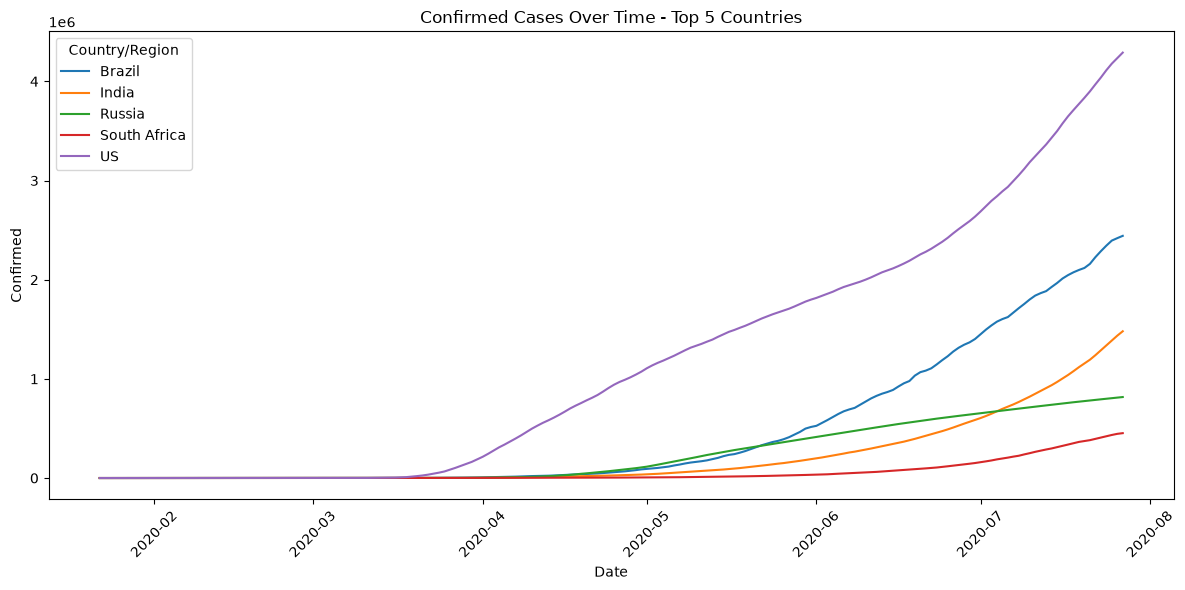

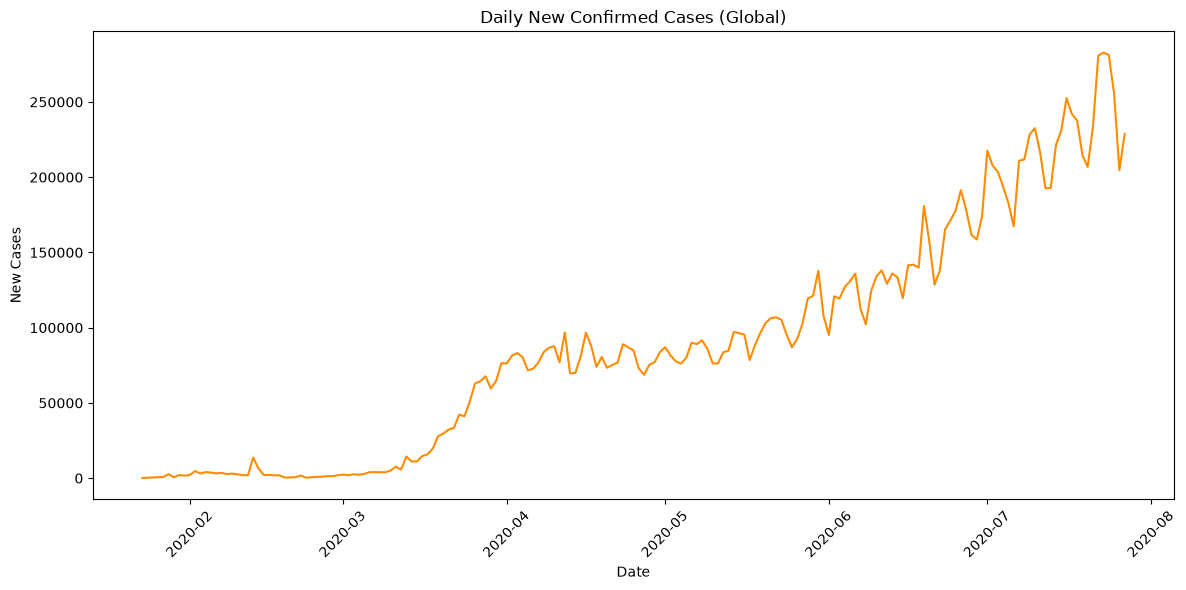

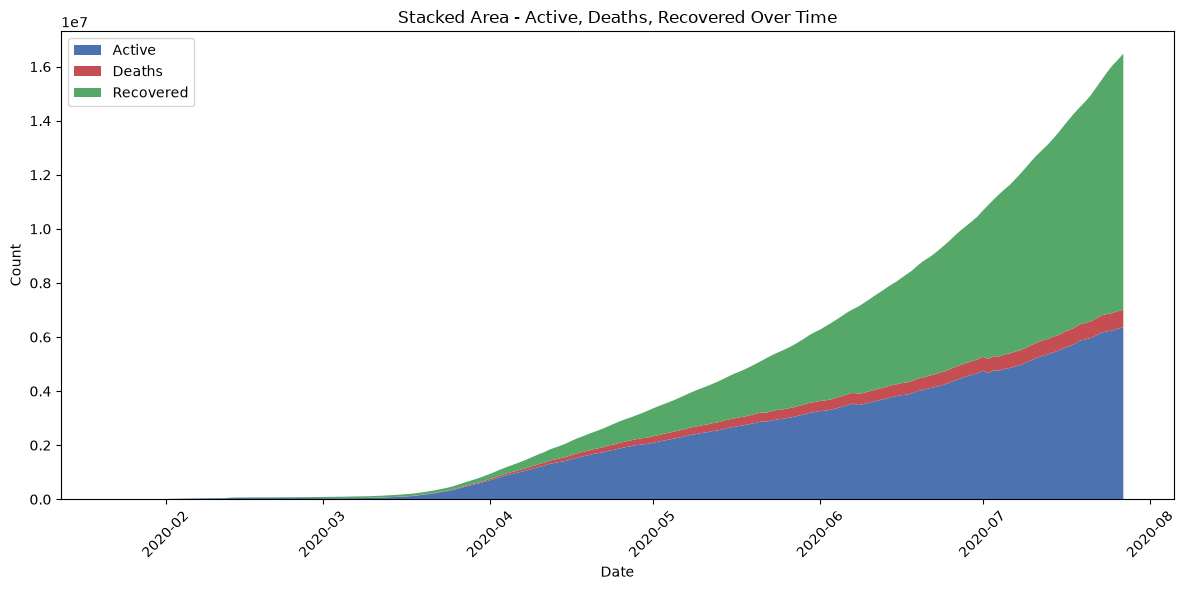

In [25]:
top_countries = covid.groupby('Country/Region')['Confirmed'].max().sort_values(ascending=False).head(5).index
country_data = covid[covid['Country/Region'].isin(top_countries)].groupby(['Date','Country/Region'])['Confirmed'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='Confirmed', hue='Country/Region', data=country_data)
plt.title('Confirmed Cases Over Time - Top 5 Countries')
plt.xlabel('Date')
plt.ylabel('Confirmed')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#So US had surprisingly more cases and china was not even in the graphs of top 5 - that's surprising considering their population 

daily_global['New_Cases'] = daily_global['Confirmed'].diff()

plt.figure(figsize=(12,6))
sns.lineplot(x='Date', y='New_Cases', data=daily_global, color='darkorange')
plt.title('Daily New Confirmed Cases (Global)')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#it had a very fluctuating yet upward trend
plt.figure(figsize=(12,6))
plt.stackplot(daily_global['Date'], 
              daily_global['Active'], daily_global['Deaths'], daily_global['Recovered'],
              labels=['Active','Deaths','Recovered'],
              colors=['#4C72B0','#C44E52','#55A868'])
plt.title('Stacked Area - Active, Deaths, Recovered Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# recovered cases were high but the amount of death and active cases were almmost identical - which was an alarming case after all





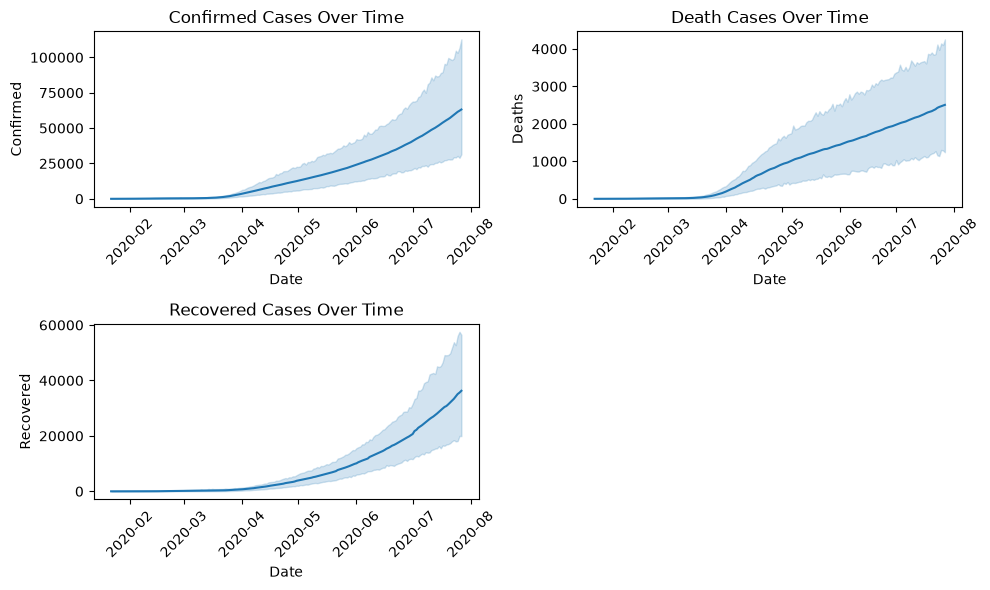

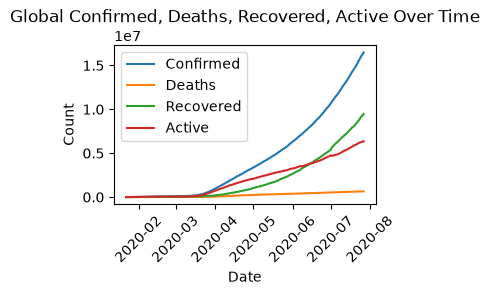

In [21]:

plt.figure(figsize=(10, 6))
plt.subplot(2,2,1)
sns.lineplot(x='Date', y='Confirmed', data=covid)
plt.xticks(rotation=45)
plt.title('Confirmed Cases Over Time')
plt.tight_layout()
plt.savefig('confirmed_vs_date.png')

# so the data clearly shows the pattern that world started to get the extreme dose of covid from the mid of March of 2020
plt.subplot(2,2,2)
sns.lineplot(x='Date', y='Deaths', data=covid)
plt.xticks(rotation=45)
plt.title('Death Cases Over Time')
plt.tight_layout()
plt.savefig('death_vs_date.png')

#line clearly shows that the cases shootup very fast 

plt.subplot(2,2,3)
sns.lineplot(x='Date', y='Recovered', data=covid)
plt.xticks(rotation=45)
plt.title('Recovered Cases Over Time')
plt.tight_layout()
plt.savefig('Recovered_vs_date.png')
plt.show()

#So the recovered graph shows that the recovery cases was faster then the death cases 

plt.subplot(2,2,4)

daily_global = covid.groupby('Date')[['Confirmed','Deaths','Recovered','Active']].sum().reset_index()

plt.plot(daily_global['Date'], daily_global['Confirmed'], label='Confirmed')
plt.plot(daily_global['Date'], daily_global['Deaths'], label='Deaths')
plt.plot(daily_global['Date'], daily_global['Recovered'], label='Recovered')
plt.plot(daily_global['Date'], daily_global['Active'], label='Active')
plt.title('Global Confirmed, Deaths, Recovered, Active Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#So the graph shows that the death cases were almost a flat line while recovery graph was chasing the confirmed graph and that was the reason why we have no covid pendamic now



In [13]:
print(covid.info())
print(covid.describe(include='all'))
covid['Date'] = pd.to_datetime(covid['Date'])
covid['Year'] = covid['Date'].dt.year


<class 'pandas.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  str    
 1   Country/Region  49068 non-null  str    
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  str    
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 3.7 MB
None
                      Province/State Country/Region           Lat  \
count                          14664          49068  49068.000000   
unique                            78            187           NaN   
top     Australian Capital Territory          China           NaN   
freq                   

In [12]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


covid = pd.read_csv("covid_19.csv")

print(f"Initial data vibe: \n {covid.head()}")
print(f"Null values in the dataset:\n {covid.isnull().sum()}")
print(f"Number of rows in dataset: {covid.shape[0]}")
print(f"Number of columns in dataset: {covid.shape[1]}")

print("\n===========CLEANING THE DATASET TIME=============\n")


Initial data vibe: 
   Province/State Country/Region       Lat       Long        Date  Confirmed  \
0            NaN    Afghanistan  33.93911  67.709953  2020-01-22          0   
1            NaN        Albania  41.15330  20.168300  2020-01-22          0   
2            NaN        Algeria  28.03390   1.659600  2020-01-22          0   
3            NaN        Andorra  42.50630   1.521800  2020-01-22          0   
4            NaN         Angola -11.20270  17.873900  2020-01-22          0   

   Deaths  Recovered  Active             WHO Region  
0       0          0       0  Eastern Mediterranean  
1       0          0       0                 Europe  
2       0          0       0                 Africa  
3       0          0       0                 Europe  
4       0          0       0                 Africa  
Null values in the dataset:
 Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths 